In [12]:
import numpy as np 
import pandas as pd 
%pip install matplotlib seaborn
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "AB_NYC_2019.csv"))
df.head()

Path to dataset files: C:\Users\pawar\.cache\kagglehub\datasets\dgomonov\new-york-city-airbnb-open-data\versions\3


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [16]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [17]:
df.shape

(48895, 16)

In [18]:
missing=df.isnull().sum()
missing[missing>0]

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

In [19]:
df['room_type'].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

<Axes: xlabel='room_type', ylabel='count'>

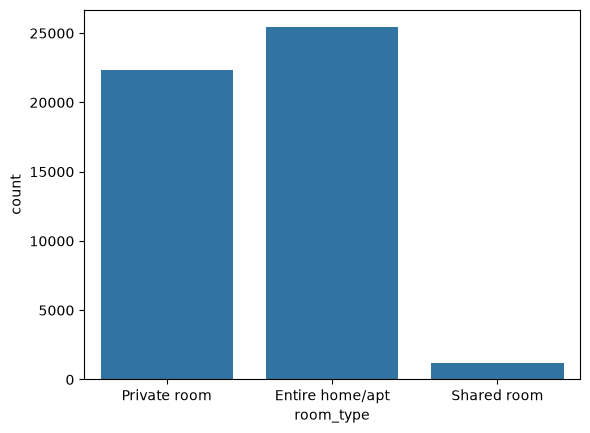

In [20]:
sns.countplot(x='room_type',data=df)

The Classes are imbalanced->Shared room is a small minority

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

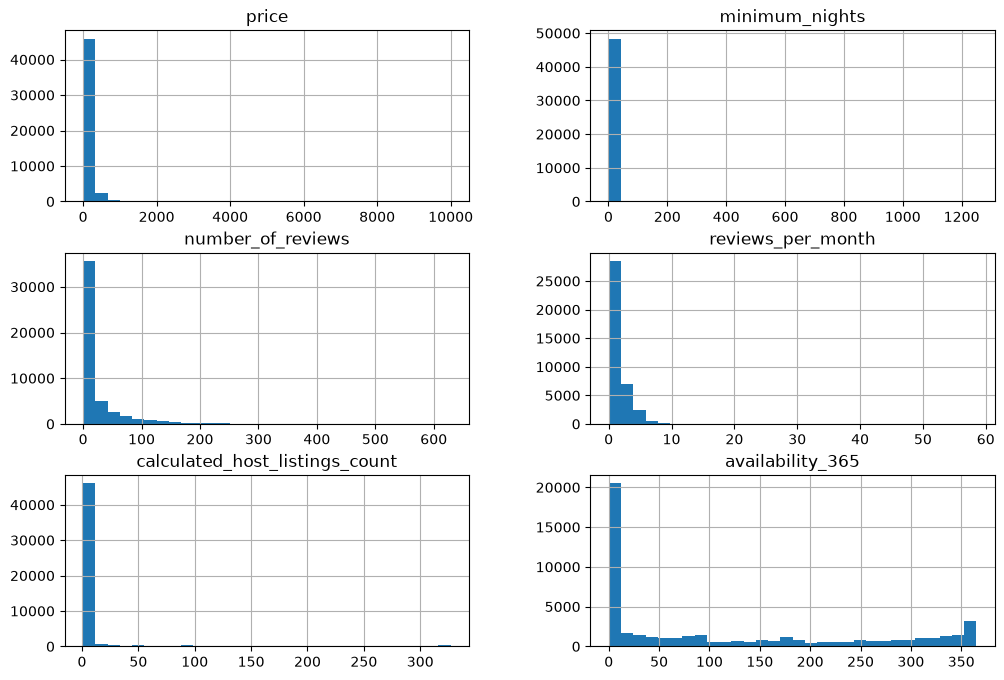

In [21]:
numerical_cols=['price','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']

df[numerical_cols].hist(bins=30,figsize=(12,8))

Unvariate Analysis-Categorical Features

<Axes: xlabel='neighbourhood_group', ylabel='count'>

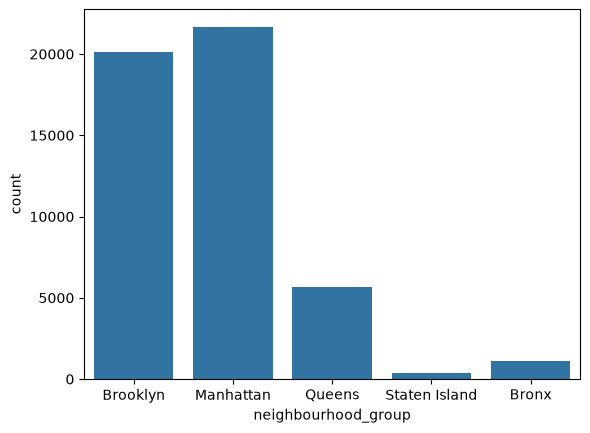

In [22]:
sns.countplot(x='neighbourhood_group',data=df)

Bivariate Analysis-Features vs Target

<Axes: xlabel='room_type', ylabel='price'>

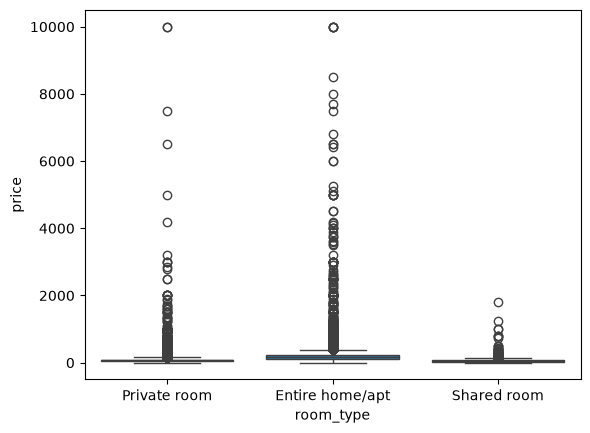

In [23]:
sns.boxplot(x='room_type',y='price',data=df)

Correlation between Numeric Features

<Axes: >

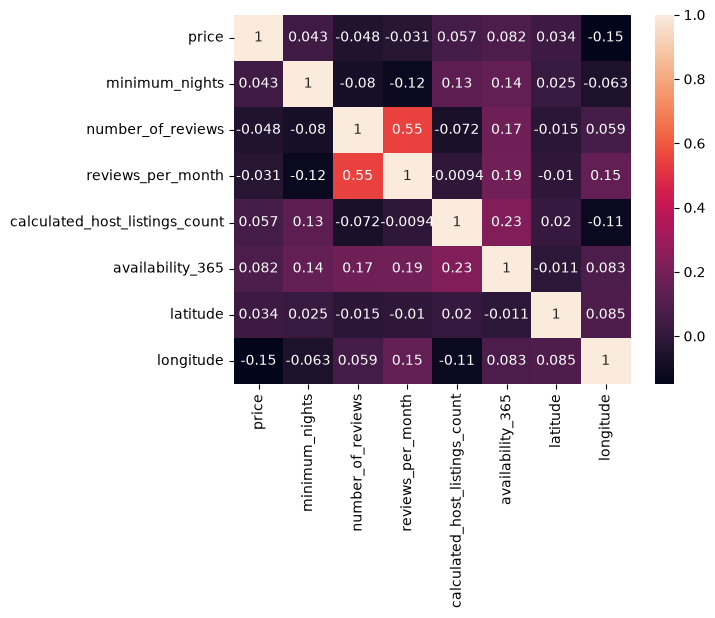

In [24]:
corr=df[numerical_cols + ['latitude','longitude']].corr()
sns.heatmap(corr,annot=True)

Geographical Distribution

<Axes: xlabel='longitude', ylabel='latitude'>

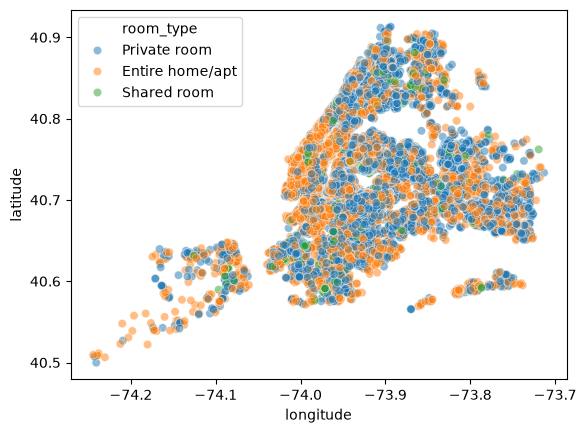

In [25]:
sns.scatterplot(x='longitude',y='latitude',data=df,hue='room_type',alpha=0.5)

Data Cleaning and  feature Engineering

In [26]:
#1->drop columns that don't help us
df_clean=df.drop(columns=['id','name','host_id','host_name','last_review'])

#2->no reviews yet means 0 reviews per month ,not missing
df_clean['reviews_per_month']=df_clean['reviews_per_month'].fillna(0)

#cap extream outliers instead of deleting rows
price_cap=df_clean['price'].quantile(0.99)
nights_cap=df_clean['minimum_nights'].quantile(0.99)

df_clean['price']=df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights']=df_clean['minimum_nights'].clip(upper=nights_cap)

df_clean.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [27]:
X=df_clean.drop(columns=['room_type'])
y=df_clean['room_type']

5. Train / Test Split

We hold out 20% of the data as a test set that is never touched during model selection or tuning — it is only used once, at the very end, to report the final, honest performance. stratify=y keeps the same class proportions in both splits, which matters because the target is imbalanced.

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [29]:
#Stratify ensure krta hai ki jab bhi hum split ya sample kare,har group(class) ka proportion maintain rahe

#Preprocessing

In [30]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder,PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [31]:
numerical_cols=['latitude','longitude','price','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']

categorical_cols=['neighbourhood_group','neighbourhood']

#1->numerical pipeline
numerical_pipeline=Pipeline(steps=[
    ('impute',SimpleImputer(strategy='median')),
    ('skewness',PowerTransformer(method='yeo-johnson')),
    ('scaler',StandardScaler())
])

#2->categorical pipeline
categorical_pipeline=Pipeline(steps=[
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor=ColumnTransformer(transformers=[
    ('numerical',numerical_pipeline,numerical_cols),
    ('categorical',categorical_pipeline,categorical_cols)
])

preprocessor

,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


**SMOTE (Synthetic Minority Oversampling)**.
  ->for class IMbalance
----------------------------------------
1. High Chances of  overfitting.
2. Data Leakage

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

In [35]:
#Algorithms 

'''class weight='Balance' tell us to pay attention on minority class or rare class.
but the problem is GradientBoosting is not support class weight so left it as it is'''

models={
    "Logistic Regression":LogisticRegression(class_weight='balanced',random_state=42),
    "Random Forest":RandomForestClassifier(class_weight='balanced',random_state=42),
    "Decision Tree":DecisionTreeClassifier(class_weight='balanced',random_state=42),
    "GradientBoostingClassifier":GradientBoostingClassifier(random_state=42)
}

for name,models in models.items():
    pipeline=Pipeline(steps=[
        ('preprocessor',preprocessor),
        ('classifier',models)
    ])

    #accuracy alone can be misleading or imbalance classes,so we use macro f1
    #both -plane accuracy and macro f1 (which treat every class equally)
    
    accuracy=cross_val_score(pipeline,X_train,y_train,cv=3,scoring='accuracy')
    macrof1=cross_val_score(pipeline,X_train,y_train,cv=3,scoring='f1_macro')

    print(f"{name} : Accuracy={accuracy.mean():.3f}, Macro F1={macrof1.mean():.3f}")
    


Logistic Regression : Accuracy=0.730, Macro F1=0.579
Random Forest : Accuracy=0.852, Macro F1=0.717
Decision Tree : Accuracy=0.787, Macro F1=0.654
GradientBoostingClassifier : Accuracy=0.850, Macro F1=0.706


**Hyperparameter Tunning**

In [38]:
from sklearn.model_selection import RandomizedSearchCV

best_pipeline=Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

param_dist={
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

search= RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    random_state=42)

search.fit(X_train, y_train)


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'classifier__max_depth': [None, 10, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], 'classifier__n_estimators': [100, 200, ...]}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [40]:
print("Best parameters found: ", search.best_params_)
print("Best Macro F1 score: ", search.best_score_)
print("Best Accuracy score: ", search.best_estimator_.score(X_test, y_test))

Best parameters found:  {'classifier__n_estimators': 300, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': None}
Best Macro F1 score:  0.7365685657822455
Best Accuracy score:  0.8553021781368239


In [42]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
best_pipeline=search.best_estimator_

y_pred=best_pipeline.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test,y_pred)}")
print(f"F1 Score: {f1_score(y_test,y_pred, average='macro')}")
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8553021781368239
F1 Score: 0.7643290143659
Classification Report:
                  precision    recall  f1-score   support

Entire home/apt       0.87      0.88      0.87      5082
   Private room       0.84      0.85      0.85      4465
    Shared room       0.84      0.44      0.57       232

       accuracy                           0.86      9779
      macro avg       0.85      0.72      0.76      9779
   weighted avg       0.86      0.86      0.85      9779



<Axes: >

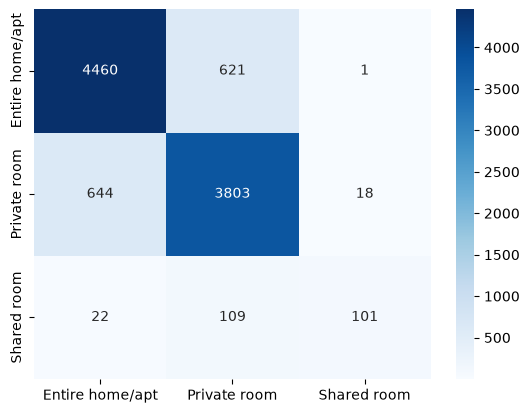

In [43]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d',cmap='Blues',xticklabels=best_pipeline.classes_,yticklabels=best_pipeline.classes_)

In [44]:
import joblib

joblib.dump(best_pipeline, 'model_pipeline.pkl')

['model_pipeline.pkl']